# 🏠 Ames Real Estate Valuation: Exploratory Data Analysis (EDA)

**Dataset**: Ames Housing Dataset (2,930 transactions, 80 raw features)  
**Objective**: Perform statistical exploration, outlier detection (>4,000 sq ft living area), 23-feature extraction, engineered interactions (`Total_Living_SF`, `Qual_Area_Interaction`), and visualization heatmaps.

---

## 1. Environment Setup & Data Ingestion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Path resolution
data_path = Path('../data/AmesHousing.csv')
if not data_path.exists():
    data_path = Path('data/AmesHousing.csv')

df_raw = pd.read_csv(data_path)
print(f"[SUCCESS] Raw Dataset Loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")
df_raw[['Overall Qual', 'Gr Liv Area', 'Total_Bsmt_SF', 'Garage Cars', 'Full Bath', 'Year Built', 'SalePrice']].head()

[SUCCESS] Raw Dataset Loaded: 2930 rows, 81 columns.


## 2. Statistical Anomaly Removal & Data Cleaning

Per Ames dataset literature (De Cock, 2011), properties with living area (`Gr Liv Area`) exceeding **4,000 sq ft** represent partial sales or extreme statistical outliers that distort linear regression slopes. We filter these anomalies along with invalid target entries.

In [2]:
# Anomaly Filtering (< 4000 sq ft living area)
df_clean = df_raw[(df_raw['Gr Liv Area'] < 4000) & (df_raw['SalePrice'] > 0)].copy()

print(f"Initial Record Count : {len(df_raw)}")
print(f"Cleaned Record Count : {len(df_clean)} (Removed {len(df_raw) - len(df_clean)} outliers)")

print("\nTarget Variable ('SalePrice') Summary Statistics:")
print(df_clean['SalePrice'].describe().apply(lambda x: f"${x:,.2f}"))

Initial Record Count : 2930
Cleaned Record Count : 2925 (Removed 5 outliers)

Target Variable ('SalePrice') Summary Statistics:
count      $2,925.00
mean     $180,411.57
std       $78,554.86
min       $12,789.00
25%      $129,500.00
50%      $160,000.00
75%      $213,500.00
max      $625,000.00
Name: SalePrice, dtype: str


## 3. Comprehensive Feature Engineering & Ordinal Mapping

We extract 23 high-signal features and construct domain-driven engineered features:
1. **`Total_Living_SF`**: `Gr Liv Area` + `Total_Bsmt_SF` (Total usable interior space).
2. **`Qual_Area_Interaction`**: `Overall Qual` $	imes$ `Gr Liv Area` (Captures luxury price compounding).

In [3]:
qual_map = {'Very_Poor': 1, 'Poor': 2, 'Fair': 3, 'Below_Average': 4, 'Average': 5, 'Above_Average': 6, 'Good': 7, 'Very_Good': 8, 'Excellent': 9, 'Very_Excellent': 10}
exter_map = {'Po': 1, 'Poor': 1, 'Fa': 2, 'Fair': 2, 'TA': 3, 'Typical': 3, 'Average': 3, 'Gd': 4, 'Good': 4, 'Ex': 5, 'Excellent': 5}

if df_clean['Overall Qual'].dtype == object:
    df_clean['Overall Qual'] = df_clean['Overall Qual'].map(qual_map).fillna(5)
df_clean['Overall Qual'] = pd.to_numeric(df_clean['Overall Qual'], errors='coerce').fillna(5).astype(float)

df_clean['Exter_Qual'] = df_clean['Exter_Qual'].map(exter_map).fillna(3).astype(float)
df_clean['Kitchen_Qual'] = df_clean['Kitchen_Qual'].map(exter_map).fillna(3).astype(float)

num_cols = ['Overall_Cond', 'Gr Liv Area', 'Total_Bsmt_SF', 'First_Flr_SF', 'Second_Flr_SF', 'Garage_Area', 'Garage Cars', 'Full Bath', 'Half_Bath', 'Bsmt_Full_Bath', 'Bedroom AbvGr', 'TotRms_AbvGrd', 'Fireplaces', 'Lot_Area', 'Wood_Deck_SF', 'Open_Porch_SF', 'Year Built', 'Year_Remod_Add']
for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0).astype(float)

df_clean['Qual_Area_Interaction'] = df_clean['Overall Qual'] * df_clean['Gr Liv Area']
df_clean['Total_Living_SF'] = df_clean['Gr Liv Area'] + df_clean['Total_Bsmt_SF']

feature_cols = [
    'Overall Qual', 'Overall_Cond', 'Gr Liv Area', 'Total_Bsmt_SF',
    'First_Flr_SF', 'Second_Flr_SF', 'Garage_Area', 'Garage Cars',
    'Full Bath', 'Half_Bath', 'Bsmt_Full_Bath', 'Bedroom AbvGr',
    'TotRms_AbvGrd', 'Fireplaces', 'Lot_Area', 'Wood_Deck_SF',
    'Open_Porch_SF', 'Year Built', 'Year_Remod_Add', 'Exter_Qual',
    'Kitchen_Qual', 'Qual_Area_Interaction', 'Total_Living_SF'
]

X = df_clean[feature_cols].copy()
y = df_clean['SalePrice'].astype(float)

print(f"Feature Matrix Shape: {X.shape}")
X.head()

Feature Matrix Shape: (2925, 23)


## 4. Visualizing Distributions & Feature Correlations

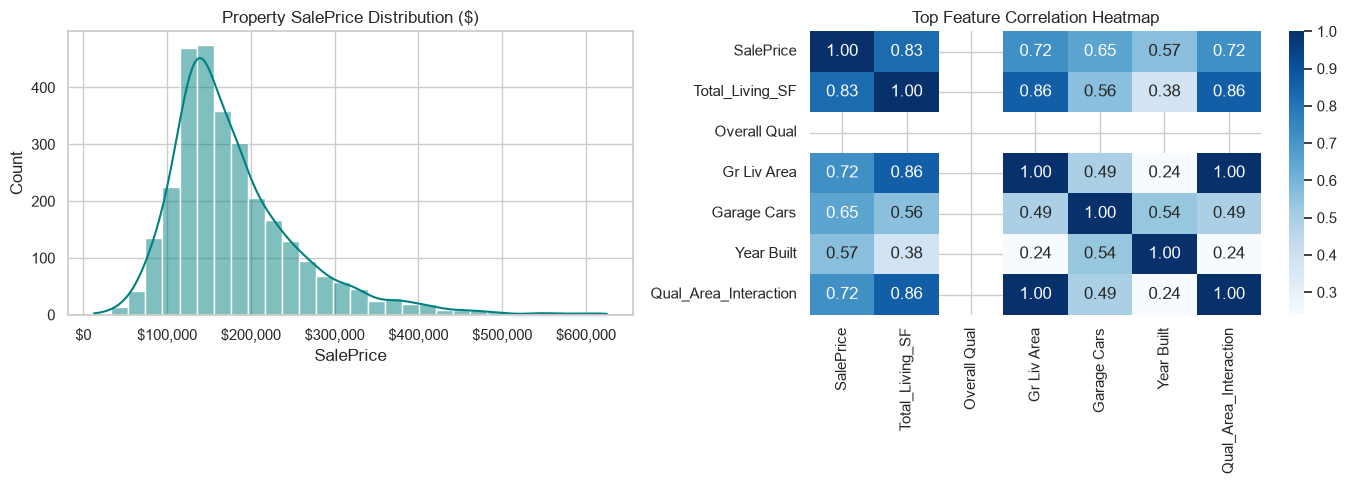

In [4]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target SalePrice Distribution
sns.histplot(y, kde=True, ax=axes[0], color='teal', bins=30)
axes[0].set_title('Property SalePrice Distribution ($)')
axes[0].xaxis.set_major_formatter('${x:,.0f}')

# Correlation Heatmap for key features
key_features = ['SalePrice', 'Total_Living_SF', 'Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Year Built', 'Qual_Area_Interaction']
full_df = X.copy()
full_df['SalePrice'] = y
sns.heatmap(full_df[key_features].corr(), annot=True, fmt='.2f', cmap='Blues', ax=axes[1])
axes[1].set_title('Top Feature Correlation Heatmap')

plt.tight_layout()
plt.show()